# NYC Property Sales Analysis

##Описание задачи

Датасет о недвижимости Нью-Йорка, содержащий сведения о продажах коммерческой и жилой недвижимости. Каждый объект характеризуется набором признаков — районом расположения, площадями, налоговым классом, категорией здания и другими параметрами. Целевая переменная — SALE PRICE, то есть цена продажи объекта.

Требуется построить предсказательную модель, которая на основе характеристик объекта недвижимости сможет оценивать его стоимость. Это задача регрессии, где требуется аппроксимировать зависимость `SALE PRICE = f(признаки)`.

## Признаки

- SALE PRICE: Цена продажи в долларах (целевая переменная)
- BOROUGH: Район Нью-Йорка (1-Манхэттен, 2-Бронкс, 3-Бруклин, 4-Куинс, 5-Стейтен-Айленд)
- NEIGHBORHOOD: Микрорайон расположения объекта
- BLOCK: Номер квартала (блока) в системе кадастра Нью-Йорка
- LOT: Номер участка (лота) в пределах квартала
- ZIP CODE: Почтовый индекс расположения объекта

- BUILDING CLASS CATEGORY: Категория здания (например, "01 ONE FAMILY DWELLINGS", "02 TWO FAMILY DWELLINGS")

- LAND SQUARE FEET: Площадь земельного участка в квадратных футах
- GROSS SQUARE FEET: Общая площадь объекта в квадратных футах

- TAX CLASS AT PRESENT: Текущий налоговый класс объекта
- TAX CLASS AT TIME OF SALE: Налоговый класс на момент продажи
- BUILDING CLASS AT PRESENT: Класс здания в настоящее время
- BUILDING CLASS AT TIME OF SALE: Класс здания на момент продажи

- RESIDENTIAL UNITS: Количество жилых единиц в здании
- COMMERCIAL UNITS: Количество коммерческих единиц в здании
- TOTAL UNITS: Общее количество единиц в здании

- SALE DATE: Дата совершения сделки
- YEAR BUILT: Год постройки здания

- Unnamed: 0: Технический индекс-идентификатор

## Особенности данных

- Разнообразие типов недвижимости: от частных домов до коммерческих зданий
-*Широкий диапазон цен: от символических сделок до многомиллионных контрактов
- Географическое разнообразие: 5 районов, 217 микрорайонов
- Временной охват: данные за разные периоды времени

In [322]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

In [258]:
import kagglehub

path = kagglehub.dataset_download("new-york-city/nyc-property-sales")

df = pd.read_csv(path + "/nyc-rolling-sales.csv")

Using Colab cache for faster access to the 'nyc-property-sales' dataset.


In [259]:
print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
df.head()

Размер датасета: (84548, 22)

Первые 5 строк:


,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,,C2,153 AVENUE B,...,5,0,5,1633,6440,1900,2,C2,6625000,2017-07-19 00:00:00
1,5,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,26,,C7,234 EAST 4TH STREET,...,28,3,31,4616,18690,1900,2,C7,-,2016-12-14 00:00:00
2,6,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,39,,C7,197 EAST 3RD STREET,...,16,1,17,2212,7803,1900,2,C7,-,2016-12-09 00:00:00
3,7,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,,C4,154 EAST 7TH STREET,...,10,0,10,2272,6794,1913,2,C4,3936272,2016-09-23 00:00:00
4,8,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,404,55,,C2,301 EAST 10TH STREET,...,6,0,6,2369,4615,1900,2,C2,8000000,2016-11-17 00:00:00


In [260]:
print("\nИнформация о типах данных:")
df.info()


Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84548 entries, 0 to 84547
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Unnamed: 0                      84548 non-null  int64 
 1   BOROUGH                         84548 non-null  int64 
 2   NEIGHBORHOOD                    84548 non-null  object
 3   BUILDING CLASS CATEGORY         84548 non-null  object
 4   TAX CLASS AT PRESENT            84548 non-null  object
 5   BLOCK                           84548 non-null  int64 
 6   LOT                             84548 non-null  int64 
 7   EASE-MENT                       84548 non-null  object
 8   BUILDING CLASS AT PRESENT       84548 non-null  object
 9   ADDRESS                         84548 non-null  object
 10  APARTMENT NUMBER                84548 non-null  object
 11  ZIP CODE                        84548 non-null  int64 
 12  RESIDENTIAL UNITS 

In [299]:
df_clean = df.copy()

df_clean['SALE PRICE'] = pd.to_numeric(df_clean['SALE PRICE'], errors='coerce')
df_clean['LAND SQUARE FEET'] = pd.to_numeric(df_clean['LAND SQUARE FEET'], errors='coerce')
df_clean['GROSS SQUARE FEET'] = pd.to_numeric(df_clean['GROSS SQUARE FEET'], errors='coerce')

categorical_columns = [
    'BOROUGH', 'NEIGHBORHOOD', 'BUILDING CLASS CATEGORY',
    'TAX CLASS AT PRESENT', 'TAX CLASS AT TIME OF SALE',
    'BUILDING CLASS AT PRESENT', 'BUILDING CLASS AT TIME OF SALE'
    ]

for col in categorical_columns:
  df_clean[col] = df_clean[col].astype('category')

df_clean['SALE DATE'] = pd.to_datetime(df_clean['SALE DATE'], errors='coerce')

df_clean = df_clean[df_clean['SALE PRICE'].notna()]

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69987 entries, 0 to 84547
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Unnamed: 0                      69987 non-null  int64         
 1   BOROUGH                         69987 non-null  category      
 2   NEIGHBORHOOD                    69987 non-null  category      
 3   BUILDING CLASS CATEGORY         69987 non-null  category      
 4   TAX CLASS AT PRESENT            69987 non-null  category      
 5   BLOCK                           69987 non-null  int64         
 6   LOT                             69987 non-null  int64         
 7   EASE-MENT                       69987 non-null  object        
 8   BUILDING CLASS AT PRESENT       69987 non-null  category      
 9   ADDRESS                         69987 non-null  object        
 10  APARTMENT NUMBER                69987 non-null  object        
 11  ZIP COD

##Разбиение на обучающую и тестовую выборки

In [262]:
X = df_clean.drop('SALE PRICE', axis=1)
y = df_clean['SALE PRICE']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

##Визуализация данных до обработки выбросов

In [263]:
y_train.describe()

,SALE PRICE
count,5.249000e+04
mean,1.262925e+06
std,8.408139e+06
min,0.000000e+00
25%,2.220000e+05
50%,5.300000e+05
75%,9.500000e+05
max,1.040000e+09


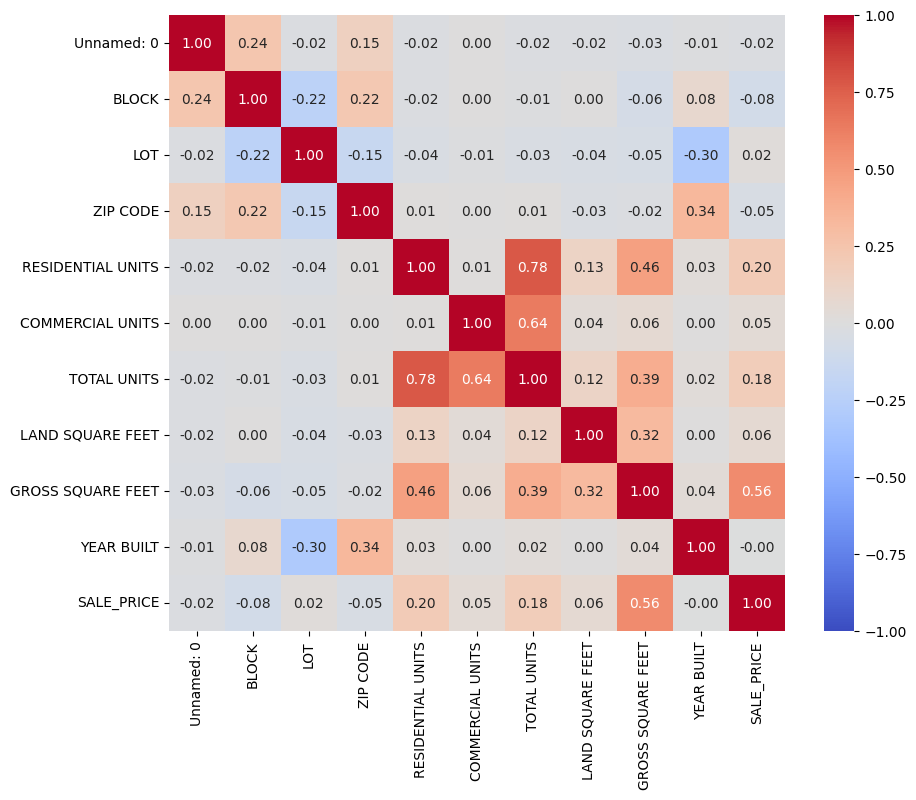

In [264]:
plt.figure(figsize=(10, 8))
numeric_data = X_train.select_dtypes(include=[np.number]).copy()
numeric_data['SALE_PRICE'] = y_train.values

corr_matrix = numeric_data.corr()

sns.heatmap(corr_matrix, square=True, annot=True, fmt='.2f', vmin=-1, vmax=1, cmap='coolwarm')
plt.show()

##Интерпретация данных

Помимо очвеидных корреляций TOTAL и RESIDENTIAL, TOTAL и COMMERCIAL UNITS, так как TOTAL UNITS должен быть суммой COMMERCIAL и RESIDENTIAL UNITS

Видна корреляция цены продажи и площади объекта (GROSS SRUARE FEET), что логично, ведь площадь объекта - одна из самых важных характеристик, влияющих на цену

Видна корреляция площади земельного участка и площади объекта, это можно объянить тем, что на больших земельных участках можно строить большие по площади объекты

Так зже видна корреляция количества жилых елдиниц и площади объекта, однако корреляции площади объекта с числом коммерческих единиц не наблюдается, это говорит о том, что жилые единицы могу быть примерно одинакового размера и их число будет расти с увеличением общей площади, а вот коммерческие единицы могут быть совершенно разных размеров, поэтому корреляции нет

Что касается распределения цен, видно, что разброс цен достаточно существенный, это произошло из-за крупных сделок и сделок за крайне низкую сумму, подобные сделки, например, могли заключаться между родственниками, для передачи имущества

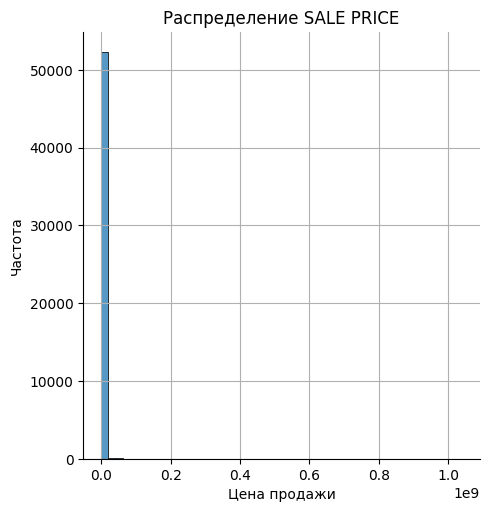

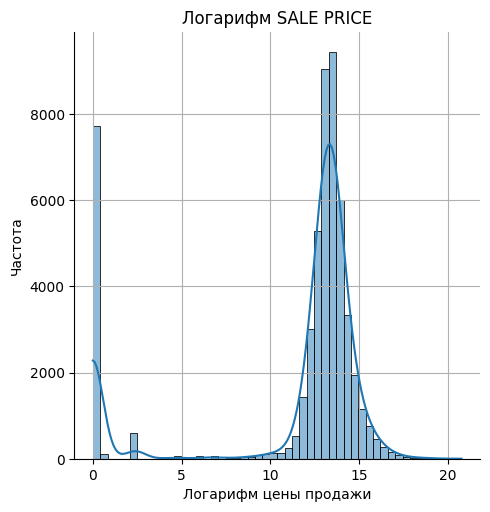

<Axes: >

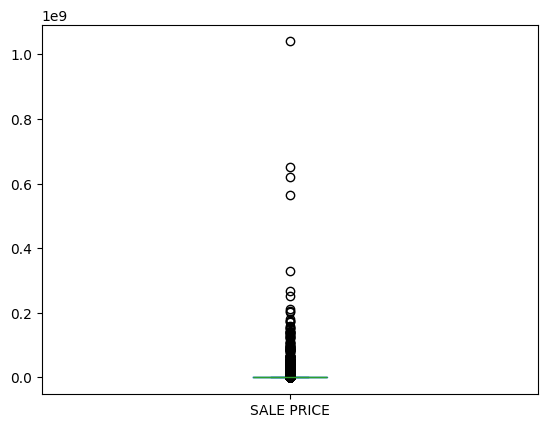

In [265]:
sns.displot(y_train, bins=50)
plt.title('Распределение SALE PRICE')
plt.xlabel('Цена продажи')
plt.ylabel('Частота')
plt.grid()

sns.displot(np.log1p(y_train), bins=50, kde=True)
plt.title('Логарифм SALE PRICE')
plt.xlabel('Логарифм цены продажи')
plt.ylabel('Частота')
plt.grid()

plt.show()

y_train.plot(kind='box')

##Обработка выбросов на обучающей выборке
В этом датасете она необходима из-за наличия большого количества в нём абсурдно малых сумм продажи, которые соответсвтуют, например, передаче собственности между родственниками

Суммы < 1000$ будут признаны несущественными

Общая площадь < 100 кв. футов слишком мала, поэтому такие значения будут признаны ошибочными

In [281]:
def remove_outliers(X, y):
    X_clean = X.copy()
    y_clean = y.copy()

    lower_bound = y_clean.quantile(0.005)
    upper_bound = y_clean.quantile(0.995)
    mask_extreme = y_clean[(y_clean < lower_bound) | (y_clean > upper_bound)].index

    X_clean = X_clean.drop(mask_extreme)
    y_clean = y_clean.drop(mask_extreme)

    lower_bound = X_clean['GROSS SQUARE FEET'].quantile(0.005)
    upper_bound = X_clean['GROSS SQUARE FEET'].quantile(0.995)
    FEET = X_clean['GROSS SQUARE FEET']
    mask_extreme = X_clean['GROSS SQUARE FEET'][(X_clean['GROSS SQUARE FEET'] < lower_bound) | (X_clean['GROSS SQUARE FEET'] > upper_bound)].index

    X_clean = X_clean.drop(mask_extreme)
    y_clean = y_clean.drop(mask_extreme)

    Q1, Q3 = y_clean.quantile([.25, .75])
    IQR = Q3 - Q1
    price_lower = max(Q1 - 1.5*IQR, 1000)
    price_upper = Q3 + 1.5*IQR

    Q1, Q3 = X_train['GROSS SQUARE FEET'].quantile([.25, .75])
    IQR = Q3 - Q1
    area_lower = max(Q1 - 1.5*IQR, 100)
    area_upper = Q3 + 1.5*IQR

    rows_to_drop = y_clean[
        (y_clean < price_lower) | (y_clean > price_upper) |
        (X_train['GROSS SQUARE FEET'] < area_lower) | (X_train['GROSS SQUARE FEET'] > area_upper)].index
    y_clean = y_clean.drop(rows_to_drop)
    X_clean = X_clean.drop(rows_to_drop)

    print(f"Размер после обработки выбросов: {X_clean.shape}")
    print(f"Удалено {len(X) - len(X_clean)} строк ({((len(X) - len(X_clean)) / len(X) * 100):.1f}%)")

    return X_clean, y_clean

X_train_clean, y_train_clean = remove_outliers(X_train, y_train)

Размер после обработки выбросов: (32384, 21)
Удалено 20106 строк (38.3%)


##Визуализация данных после обработки выбросов

In [267]:
y_train_clean.describe()

,SALE PRICE
count,3.238400e+04
mean,6.686737e+05
std,4.105597e+05
min,1.000000e+03
25%,3.750000e+05
50%,5.800000e+05
75%,8.655120e+05
max,2.015605e+06


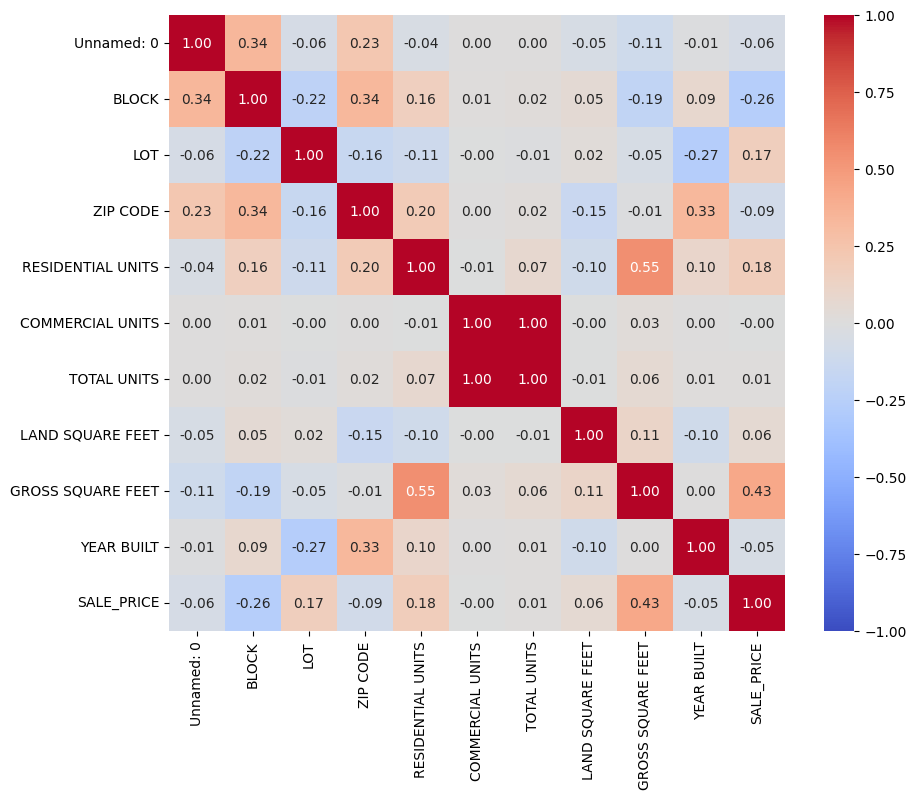

In [268]:
plt.figure(figsize=(10, 8))
numeric_data = X_train_clean.select_dtypes(include=[np.number]).copy()
numeric_data['SALE_PRICE'] = y_train_clean.values

corr_matrix = numeric_data.corr()

sns.heatmap(corr_matrix, square=True, annot=True, fmt='.2f', vmin=-1, vmax=1, cmap='coolwarm')
plt.show()

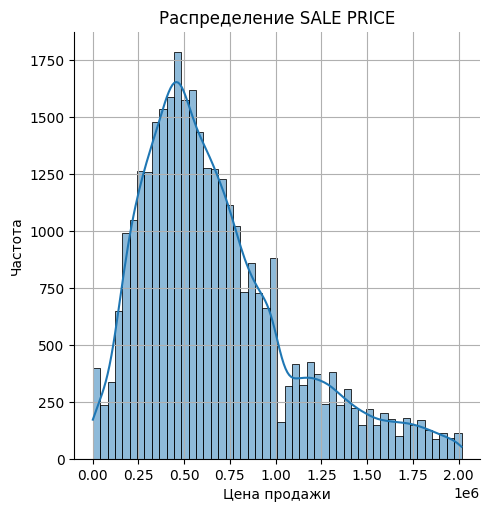

<Axes: >

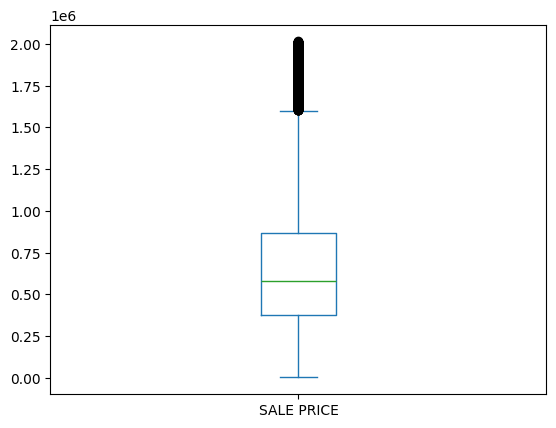

In [269]:
sns.displot(y_train_clean, bins=50, kde=True)
plt.title('Распределение SALE PRICE')
plt.xlabel('Цена продажи')
plt.ylabel('Частота')
plt.grid()

plt.show()

y_train_clean.plot(kind='box')

После обработки выбросов стало видно. что большая часть сделок заключается на сумму около 0.5 * 10^6$

Осталась видна корреляция между ценой и площадью объекта, а так же между площадью объекта и количеством жилых единиц

In [270]:
!pip install feature_engine

In [323]:
from feature_engine.selection import DropFeatures

features_to_drop = ['Unnamed: 0', 'EASE-MENT', 'SALE DATE']

ppl = Pipeline([
    ('drop_columns', DropFeatures(features_to_drop)),

    ('impute', ColumnTransformer([
        ('num', make_pipeline(
            SimpleImputer(strategy='median'),
            StandardScaler()),
            make_column_selector(dtype_include=np.number)
        ),
        ('cat', make_pipeline(
            SimpleImputer(strategy='most_frequent'),
            OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')),
            make_column_selector(dtype_include='category')
        )],
        remainder='drop'
    )),

    ('regressor', KNeighborsRegressor())
])

print(ppl)

Pipeline(steps=[('drop_columns',
                 DropFeatures(features_to_drop=['Unnamed: 0', 'EASE-MENT',
                                                'SALE DATE'])),
                ('impute',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x79d035d08740>),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),

##Причины выбора модели

- Логика "похожие объекты → похожие цены" интуитивно понятна для риелторов и оценщиков. Можно явно показать аналогичные объекты из базы данных для обоснования цены

- Простота настройки модели - один легко подбираемы гиперпараметр

In [306]:
X_train_clean, y_train_clean = remove_outliers(X_train, y_train)

param_grid = {
    'regressor__n_neighbors': [3, 5, 7, 10, 15, 20, 25, 30],
}

grid_search = GridSearchCV(
    ppl,
    param_grid,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

print("Запуск GridSearch с новым пайплайном...")
grid_search.fit(X_train_clean, y_train_clean)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший score (MSE): {-grid_search.best_score_:.4f}")

=== ПОДБОР ГИПЕРПАРАМЕТРОВ С НОВЫМ ПАЙПЛАЙНОМ ===
Размер после обработки выбросов: (32384, 21)
Удалено 20106 строк (38.3%)
Запуск GridSearch с новым пайплайном...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Лучшие параметры: {'regressor__n_neighbors': 10}
Лучший score (negative MSE): 80177735310.0375


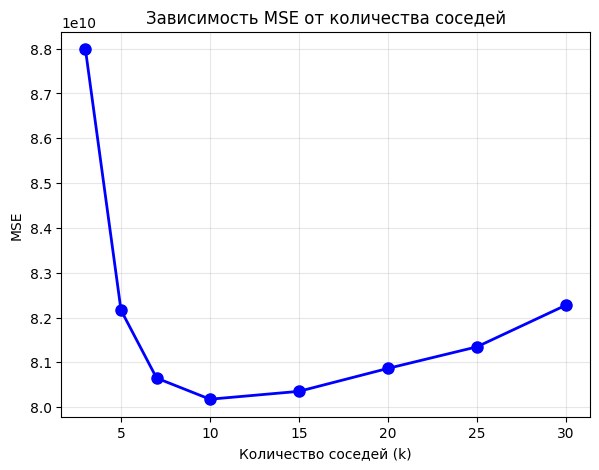

In [303]:
results = grid_search.cv_results_

results_df = pd.DataFrame(results)

k_values = param_grid['regressor__n_neighbors']

mse_by_k = []
for k in k_values:
    mask = results_df['param_regressor__n_neighbors'] == k
    if mask.any():
        mse_scores = -results_df[mask]['mean_test_score']
        mse_by_k.append(mse_scores.mean())

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, mse_by_k, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Количество соседей (k)')
plt.ylabel('MSE')
plt.title('Зависимость MSE от количества соседей')
plt.grid(True, alpha=0.3)

In [320]:
ppl.set_params(regressor__n_neighbors=grid_search.best_params_['regressor__n_neighbors'])
ppl.fit(X_train_clean, y_train_clean)
y_train_predict = ppl.predict(X_train_clean)
y_test_predict = ppl.predict(X_test)
RMSE_train = mean_squared_error(y_train_clean, y_train_predict)**.5
RMSE_test  = mean_squared_error(y_test,  y_test_predict)**.5
RMSE_train, RMSE_test

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2, 4, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


(252772.87627234843, 17551422.50172699)

## Выводы
Мы видим существенную разницу в ошибках на обучающей и тестовой выборке, это говорит о серьёзном переобучении модели, она идеально запомнила обучающие данные

Вероятно такой рост ошибок произошёл из-за существенного количесва выбросов в тестовой и обучающей выборках: в обучающей все выбросы были убраны, а вот в тестовой мы не можем с ними так поступить, отсюда и растущая ошибка